In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import LyapunovExponents

In [3]:
A = np.array([[2.0]])

In [4]:
def f_linear(x):
    x = np.atleast_1d(x)
    y = A @ x
    return np.atleast_1d(y)

def f_nl(x):
    if x.shape[0] != 2:
        raise ValueError("Expected a 2D state vector (size 2), got shape{}".format(x.shape))
    
    return np.array([x[0] - x[0]**3,
                    -x[1]])

In [5]:
# --- Initialize the Lyapunov calculator ---
lyap_calc = LyapunovExponents(dim=2, dt=1e-3, continuous=True, integrator='rk4')

# --- Range of integration times to test ---
T_values = np.linspace(1.0, 50, 20)  # from 1 to 50 in 20 steps
lyap_estimates = np.zeros((len(T_values), 2))

x0 = np.array([0.8, 0.0])

# --- Loop over T and compute Lyapunov exponents ---
for i in range(len(T_values)):
    lams = lyap_calc.compute(f_nl, x0, T=T_values[i])
    lyap_estimates[i, :] = lams

AttributeError: 'numpy.ndarray' object has no attribute 'device'

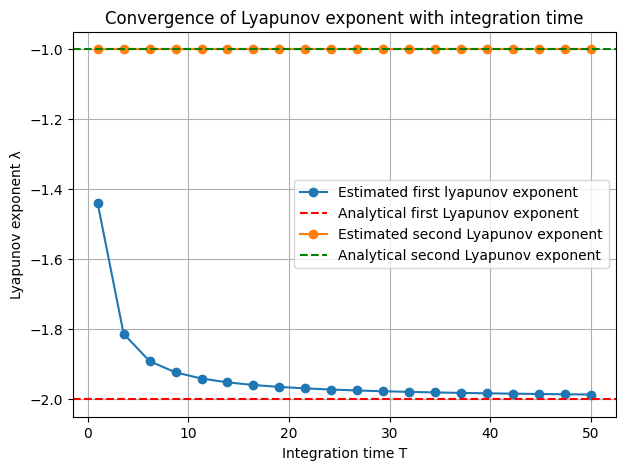

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(T_values, lyap_estimates[:, 0], 'o-', label='Estimated first lyapunov exponent')
plt.axhline(-2.0, color='r', linestyle='--', label='Analytical first Lyapunov exponent')
plt.plot(T_values, lyap_estimates[:, 1], 'o-', label="Estimated second Lyapunov exponent")
plt.axhline(-1.0, color='g', linestyle='--', label='Analytical second Lyapunov exponent')
plt.xlabel("Integration time T")
plt.ylabel("Lyapunov exponent λ")
plt.title("Convergence of Lyapunov exponent with integration time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def f_6(x):
    if x.shape[0] != 3:
        raise ValueError("We need the state to be three dimensional, with the third dimension being a time augmentation")
    
    x1, x2, t = x

    fx1 = torch.cos(4*t) * x1 + (torch.sin(4*t) - 2) * x2
    fx2 = (torch.sin(4*t) + 2) * x1 - x2 * torch.cos(4*t)
    fx3 = torch.tensor(1.0, dtype=x.dtype)

    return torch.stack([fx1, fx2, fx3])

def jac(x):
    if x.shape[0] != 3:
        raise ValueError("We need the state to be three dimensional, with the third dimension being a time augmentation")
    
    x1, x2, t = x
    J = np.array([
        [np.cos(4*t), np.sin(4*t) - 2, -4 * x1 * np.sin(4*t) + 4 * x2 * np.cos(4*t)],
        [np.sin(4*t) + 2, -np.cos(4*t), 4 * x1 * np.cos(4*t) + 4 * x2 * np.sin(4*t)],
        [0, 0, 0]
        ])
    return J

def jac_ag(x):

    x = x.clone().detach().requires_grad_(True)

    J = torch.autograd.functional.jacobian(f_6, x)

    return J

T_values = torch.linspace(0.1, 5, 20)  # from 1 to 50 in 20 steps

lyap_calc6 = LyapunovExponents(dim=3, dt=1e-3, continuous=True, integrator='rk4')


x0 = torch.tensor([4.2, 7.9])
x_aug = torch.cat([x0, torch.tensor([0.0])], dim=0)   

lyap_estimates6 = torch.zeros((len(T_values), 3))


for i in range(len(T_values)):
    lams = lyap_calc6.compute(f_6, x_aug, jac=jac_ag, T=T_values[i], sample_every=1)
    lyap_estimates6[i, :] = lams

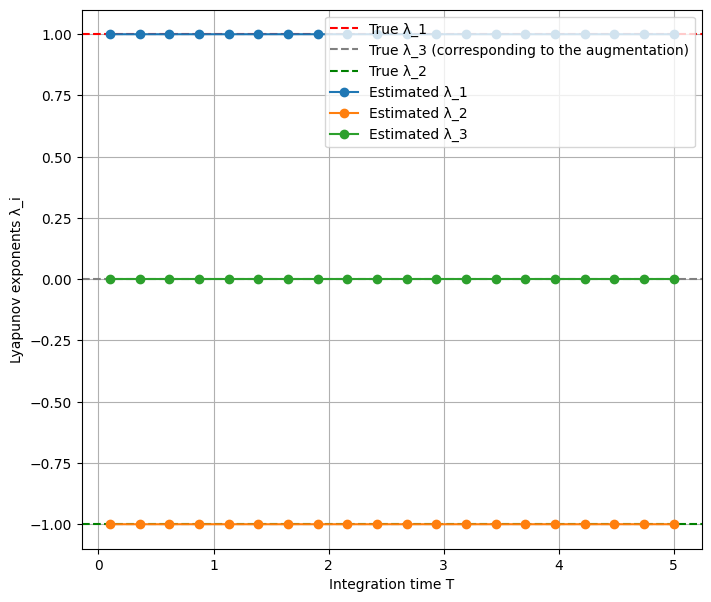

In [ ]:
plt.figure(figsize=(8,7))
plt.axhline(1.0, color='r', linestyle='--', label="True λ_1")
plt.axhline(0.0, color='gray', linestyle='--', label="True λ_3 (corresponding to the augmentation)")
plt.axhline(-1.0, color='g', linestyle='--', label="True λ_2")
plt.plot(T_values, lyap_estimates6[:,0], 'o-', label="Estimated λ_1")
plt.plot(T_values, lyap_estimates6[:,1], 'o-', label="Estimated λ_2")
plt.plot(T_values, lyap_estimates6[:,2], 'o-', label="Estimated λ_3")
plt.xlabel("Integration time T")
plt.ylabel("Lyapunov exponents λ_i")
plt.legend()
plt.grid(True)
plt.show()